<a href="https://colab.research.google.com/github/Code-eram/skills-introduction-to-github/blob/main/Delhivery_Business_CaseStudy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Delhivery Business CaseStudy

"To develop a data-driven framework and predictive model utilizing raw logistical data (e.g., trip segments, time stamps, distances) to accurately forecast key operational metrics—most critically, the Estimated Time of Arrival (ETA) or total delivery duration for every shipment. This framework must also systematically identify operational bottlenecks, measure the true efficiency gap between planned and actual delivery times, and generate actionable business recommendations to enhance logistics quality, service reliability, and overall operational excellence."

Firsty, Importing all the neccessary libraries required for data visualization and to drive the Insights

In [165]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

Using the Pandas read_csv , Reading the dataset

In [166]:
data=pd.read_csv('delhivery_data.csv')

To check the columns present and its content , selecting only the first 5 rows from dataset by default

In [167]:
data.head(5)

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:27:55,10.435660,14.0,11.0,11.9653,1.272727,14.0,11.0,11.9653,1.272727
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:17:55,18.936842,24.0,20.0,21.7243,1.200000,10.0,9.0,9.7590,1.111111
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:01:19.505586,27.637279,40.0,28.0,32.5395,1.428571,16.0,7.0,10.8152,2.285714
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:39:57,36.118028,62.0,40.0,45.5620,1.550000,21.0,12.0,13.0224,1.750000
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:33:55,39.386040,68.0,44.0,54.2181,1.545455,6.0,5.0,3.9153,1.200000


To know the total rows and columns present , and each column bearing the total count of non-null rows and its datatype  , using the .info()  and shape.

In [168]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81922 entries, 0 to 81921
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   data                            81922 non-null  object 
 1   trip_creation_time              81922 non-null  object 
 2   route_schedule_uuid             81922 non-null  object 
 3   route_type                      81922 non-null  object 
 4   trip_uuid                       81922 non-null  object 
 5   source_center                   81922 non-null  object 
 6   source_name                     81751 non-null  object 
 7   destination_center              81922 non-null  object 
 8   destination_name                81808 non-null  object 
 9   od_start_time                   81922 non-null  object 
 10  od_end_time                     81922 non-null  object 
 11  start_scan_to_end_scan          81922 non-null  float64
 12  is_cutoff                       

In [169]:
data.shape

(81922, 24)

##1.Basic Data Cleaning



1.1. Handle missing values in the data.

 Dropping the null value rows since only few are present , we will eradicate those


In [170]:
data = data.dropna(subset=['source_name', 'destination_name'])


rounding off the distance

In [171]:
data['actual_distance_to_destination'] = data['actual_distance_to_destination'].round(2)


finding the state , city of both source and destination

In [172]:
# Extract state from destination
data['dest_state'] = data['destination_name'].str.extract(r'\((.*?)\)')

# Remove the state part to split city/place
data['dest_clean'] = data['destination_name'].str.replace(r'\(.*?\)', '', regex=True).str.strip()

# Split by underscore into two parts only: city, place
data[['dest_city', 'dest_place']] = data['dest_clean'].str.split('_', n=1, expand=True)


In [173]:
# Extract state from source
data['src_state'] = data['source_name'].str.extract(r'\((.*?)\)')

# Remove the state part
data['src_clean'] = data['source_name'].str.replace(r'\(.*?\)', '', regex=True).str.strip()

# Split city and place
data[['src_city', 'src_place']] = data['src_clean'].str.split('_', n=1, expand=True)


In [174]:
data.head(3)

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,segment_osrm_distance,segment_factor,dest_state,dest_clean,dest_city,dest_place,src_state,src_clean,src_city,src_place
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,11.9653,1.272727,Gujarat,Khambhat_MotvdDPP_D,Khambhat,MotvdDPP_D,Gujarat,Anand_VUNagar_DC,Anand,VUNagar_DC
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,9.7590,1.111111,Gujarat,Khambhat_MotvdDPP_D,Khambhat,MotvdDPP_D,Gujarat,Anand_VUNagar_DC,Anand,VUNagar_DC
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,10.8152,2.285714,Gujarat,Khambhat_MotvdDPP_D,Khambhat,MotvdDPP_D,Gujarat,Anand_VUNagar_DC,Anand,VUNagar_DC


1.2. Converting time columns into pandas datetime.



In [175]:
data['trip_creation_time'] = pd.to_datetime(data['trip_creation_time'], errors='coerce')


In [176]:
data['trip_year'] = data['trip_creation_time'].dt.year
data['trip_month'] = data['trip_creation_time'].dt.month
data['trip_day'] = data['trip_creation_time'].dt.day
data['trip_hour'] = data['trip_creation_time'].dt.hour
data['trip_minute'] = data['trip_creation_time'].dt.minute
data['trip_weekday'] = data['trip_creation_time'].dt.weekday  # Monday=0
data['trip_week'] = data['trip_creation_time'].dt.isocalendar().week
data['is_weekend'] = data['trip_weekday'].isin([5, 6]).astype(int)


In [177]:
# Convert to datetime (if not already)
data['od_start_time'] = pd.to_datetime(data['od_start_time'])
data['od_end_time'] = pd.to_datetime(data['od_end_time'])

# Calculate time difference in hours
data['od_time_diff_hour'] = (data['od_end_time'] - data['od_start_time']).dt.total_seconds() / 3600

# Drop original columns (optional)
data.drop(['od_start_time', 'od_end_time'], axis=1, inplace=True)


1.3. Analyze structure & characteristics of the dataset, this is done post removing the null rows and chaning the time cols to pandas datetime


In [178]:
print(data.shape)
print(data.info())
print(data.describe(include='all'))


(81640, 39)
<class 'pandas.core.frame.DataFrame'>
Index: 81640 entries, 0 to 81921
Data columns (total 39 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   data                            81640 non-null  object        
 1   trip_creation_time              81640 non-null  datetime64[ns]
 2   route_schedule_uuid             81640 non-null  object        
 3   route_type                      81640 non-null  object        
 4   trip_uuid                       81640 non-null  object        
 5   source_center                   81640 non-null  object        
 6   source_name                     81640 non-null  object        
 7   destination_center              81640 non-null  object        
 8   destination_name                81640 non-null  object        
 9   start_scan_to_end_scan          81640 non-null  float64       
 10  is_cutoff                       81640 non-null  bool          


In [179]:
data.nunique()


,0
data,2
trip_creation_time,8303
route_schedule_uuid,1385
route_type,2
trip_uuid,8303
source_center,1406
source_name,1406
destination_center,1376
destination_name,1376
start_scan_to_end_scan,1524


checking the correation between the numerical coumns

In [180]:
data.corr(numeric_only=True)


,start_scan_to_end_scan,is_cutoff,cutoff_factor,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,...,segment_factor,trip_year,trip_month,trip_day,trip_hour,trip_minute,trip_weekday,trip_week,is_weekend,od_time_diff_hour
start_scan_to_end_scan,1.000000,0.299008,0.782881,0.783213,0.784886,0.783239,0.782031,-0.026760,0.095990,0.231628,...,-0.019501,NaN,0.055975,-0.020661,-0.005528,-0.013629,0.004037,0.056283,0.019248,1.000000
is_cutoff,0.299008,1.000000,0.190557,0.191328,0.167702,0.186264,0.187980,-0.135016,-0.005119,0.229143,...,-0.103191,NaN,0.013712,-0.012379,-0.013699,-0.009014,0.001973,0.005009,0.006309,0.299006
cutoff_factor,0.782881,0.190557,1.000000,0.999986,0.977332,0.995893,0.997171,-0.067802,0.047552,0.165889,...,-0.030971,NaN,0.047323,-0.021630,-0.002504,-0.012583,0.001826,0.043201,0.014264,0.782879
actual_distance_to_destination,0.783213,0.191328,0.999986,1.000000,0.977272,0.995927,0.997201,-0.067992,0.047856,0.166888,...,-0.031109,NaN,0.047044,-0.021657,-0.002338,-0.012580,0.001916,0.042739,0.014283,0.783211
actual_time,0.784886,0.167702,0.977332,0.977272,1.000000,0.976413,0.977737,0.030677,0.126448,0.179093,...,0.015228,NaN,0.042930,-0.015324,-0.007989,-0.011132,-0.000547,0.044809,0.010718,0.784885
osrm_time,0.783239,0.186264,0.995893,0.995927,0.976413,1.000000,0.999105,-0.072708,0.052487,0.185631,...,-0.032327,NaN,0.044743,-0.019236,-0.004163,-0.013161,0.002271,0.042102,0.013659,0.783238
osrm_distance,0.782031,0.187980,0.997171,0.997201,0.977737,0.999105,1.000000,-0.068771,0.051328,0.177248,...,-0.031167,NaN,0.045664,-0.019496,-0.004623,-0.012999,0.001632,0.043321,0.013821,0.782029
factor,-0.026760,-0.135016,-0.067802,-0.067992,0.030677,-0.072708,-0.068771,1.000000,0.531735,-0.058372,...,0.550805,NaN,-0.014918,0.018393,-0.053564,0.000794,-0.007065,0.001669,-0.006870,-0.026757
segment_actual_time,0.095990,-0.005119,0.047552,0.047856,0.126448,0.052487,0.051328,0.531735,1.000000,0.420726,...,0.462617,NaN,-0.009353,0.007230,-0.002450,0.008226,0.001769,-0.005713,0.003380,0.095991
segment_osrm_time,0.231628,0.229143,0.165889,0.166888,0.179093,0.185631,0.177248,-0.058372,0.420726,1.000000,...,-0.067690,NaN,-0.002792,-0.000747,0.012552,0.003031,0.011971,-0.008335,0.014874,0.231624


##2. Merging the  required rows

2.1. grouping by segment


It is important to combine these columns in order to get the source and final destination of each trip , and assigning it to a column named segment key

In [181]:
data['segment_key'] = data['trip_uuid'].astype(str) + '_' +data['src_state']+'_'+ data['src_city'] + '-' + data['dest_state']+'_'+data['dest_city']
data['segment_key']

,segment_key
0,trip-153741093647649320_Gujarat_Anand-Gujarat_...
1,trip-153741093647649320_Gujarat_Anand-Gujarat_...
2,trip-153741093647649320_Gujarat_Anand-Gujarat_...
3,trip-153741093647649320_Gujarat_Anand-Gujarat_...
4,trip-153741093647649320_Gujarat_Anand-Gujarat_...
...,...
81917,trip-153778059310553932_Bihar_Sasaram-Haryana_...
81918,trip-153778059310553932_Bihar_Sasaram-Haryana_...
81919,trip-153778059310553932_Bihar_Sasaram-Haryana_...
81920,trip-153778059310553932_Bihar_Sasaram-Haryana_...


2.2. summing up all segments based on the segment key , using groupby , cause these are all numeric fields

In [182]:
data['segment_actual_time_sum'] = data.groupby('segment_key')['segment_actual_time'].cumsum()
data['segment_osrm_distance_sum'] = data.groupby('segment_key')['segment_osrm_distance'].cumsum()
data['segment_osrm_time_sum'] = data.groupby('segment_key')['segment_osrm_time'].cumsum()


In [183]:
data[['segment_actual_time_sum','segment_osrm_distance_sum','segment_osrm_time_sum']]

,segment_actual_time_sum,segment_osrm_distance_sum,segment_osrm_time_sum
0,14.0,11.9653,11.0
1,24.0,21.7243,20.0
2,40.0,32.5395,27.0
3,61.0,45.5619,39.0
4,67.0,49.4772,44.0
...,...,...,...
81917,616.0,633.0570,480.0
81918,644.0,656.4633,496.0
81919,676.0,679.0530,511.0
81920,689.0,702.2455,527.0


2.3.Final total per segment

In [184]:
segment_summary = data.groupby('segment_key').agg({
    'segment_actual_time': 'sum',
    'segment_osrm_distance': 'sum',
    'segment_osrm_time': 'sum'
}).reset_index()


In [185]:
segment_summary

,segment_key,segment_actual_time,segment_osrm_distance,segment_osrm_time
0,trip-153671042288605164_Karnataka_Doddablpur-K...,46.0,28.1995,26.0
1,trip-153671042288605164_Karnataka_Tumkur-Karna...,95.0,55.9899,39.0
2,trip-153671052974046625_Karnataka_Bellary-Karn...,147.0,63.6461,45.0
3,trip-153671052974046625_Karnataka_Hospet-Karna...,63.0,29.5697,26.0
4,trip-153671052974046625_Karnataka_Sandur-Karna...,130.0,53.5761,44.0
...,...,...,...,...
14574,trip-153861095625827784_Punjab_Chandigarh-Punj...,33.0,28.8991,28.0
14575,trip-153861104386292051_Haryana_FBD-Haryana_Fa...,21.0,16.0883,11.0
14576,trip-153861106442901555_Uttar Pradesh_Kanpur-U...,281.0,104.8866,88.0
14577,trip-153861118270144424_Karnataka_Hospet-Karna...,41.0,28.0484,25.0


2.a.Aggregating at segment level

This is required to calculate metrics that involves duration,speed etc. summing all the numerical columns ,and keeing all the categorical rows intact .

In [186]:
segment_dict = {
    # Identifiers - remain same across rows
    'trip_uuid': 'first',
    'source_center': 'first',
    'destination_center': 'first',

    # time-related numeric fields → sum
    'segment_actual_time': 'sum',
    'segment_osrm_distance': 'sum',
    'segment_osrm_time': 'sum'
}

In [187]:
segment_dict

{'trip_uuid': 'first',
 'source_center': 'first',
 'destination_center': 'first',
 'segment_actual_time': 'sum',
 'segment_osrm_distance': 'sum',
 'segment_osrm_time': 'sum'}

combining all rows belonging to the same segment, using groupby.

In [188]:
segment_data = data.groupby('segment_key').agg(segment_dict).reset_index()
segment_data

,segment_key,trip_uuid,source_center,destination_center,segment_actual_time,segment_osrm_distance,segment_osrm_time
0,trip-153671042288605164_Karnataka_Doddablpur-K...,trip-153671042288605164,IND561203AAB,IND562101AAA,46.0,28.1995,26.0
1,trip-153671042288605164_Karnataka_Tumkur-Karna...,trip-153671042288605164,IND572101AAA,IND561203AAB,95.0,55.9899,39.0
2,trip-153671052974046625_Karnataka_Bellary-Karn...,trip-153671052974046625,IND583101AAA,IND583201AAA,147.0,63.6461,45.0
3,trip-153671052974046625_Karnataka_Hospet-Karna...,trip-153671052974046625,IND583201AAA,IND583119AAA,63.0,29.5697,26.0
4,trip-153671052974046625_Karnataka_Sandur-Karna...,trip-153671052974046625,IND583119AAA,IND583101AAA,130.0,53.5761,44.0
...,...,...,...,...,...,...,...
14574,trip-153861095625827784_Punjab_Chandigarh-Punj...,trip-153861095625827784,IND160002AAC,IND140603AAA,33.0,28.8991,28.0
14575,trip-153861104386292051_Haryana_FBD-Haryana_Fa...,trip-153861104386292051,IND121004AAB,IND121004AAA,21.0,16.0883,11.0
14576,trip-153861106442901555_Uttar Pradesh_Kanpur-U...,trip-153861106442901555,IND209304AAA,IND208006AAA,281.0,104.8866,88.0
14577,trip-153861118270144424_Karnataka_Hospet-Karna...,trip-153861118270144424,IND583201AAA,IND583119AAA,41.0,28.0484,25.0


In [189]:
segment_data = segment_data.sort_values(
    by=["segment_key"],
    ascending=[True]
)

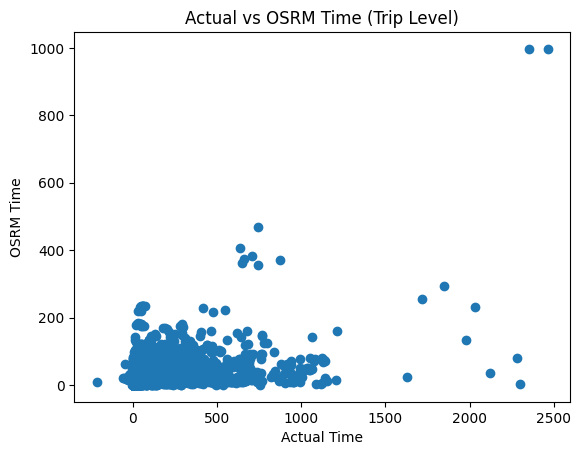

In [190]:
plt.scatter(data["segment_actual_time"],data["segment_osrm_time"])
plt.xlabel("Actual Time")
plt.ylabel("OSRM Time")
plt.title("Actual vs OSRM Time (Trip Level)")
plt.show()

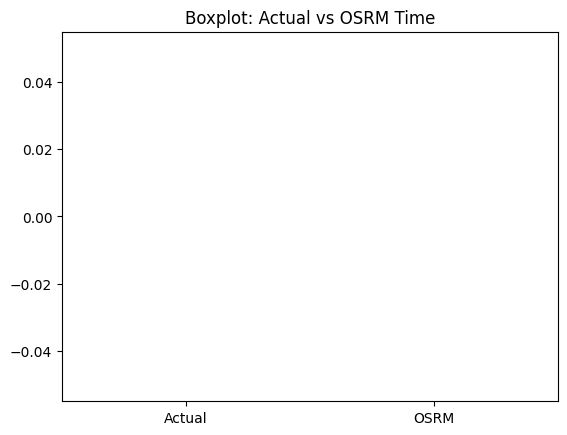

In [191]:
plt.boxplot([data["segment_actual_time"],data["segment_osrm_time"]],
            labels=["Actual", "OSRM"])
plt.title("Boxplot: Actual vs OSRM Time")
plt.show()

3.Feature Engineering

In [192]:
# Extract state using regex
data['destination_state'] = data['destination_name'].str.extract(r'\((.*?)\)', expand=False)

# Remove the state part and parentheses from destination_name
cleaned_destination_name = data['destination_name'].str.replace(r'\s*\(.*\)\s*$', '', regex=True)

# Split the cleaned name by '_'
split_parts = cleaned_destination_name.str.split('_', expand=True)

# Assign destination_city, destination_place, destination_code
# Use .get() to safely access columns, providing None if they don't exist
data['destination_city'] = split_parts.get(0)
data['destination_place'] = split_parts.get(1)
data['destination_code'] = split_parts.get(2)

In [193]:
# Extract state using regex from source_name
data['source_state'] = data['source_name'].str.extract(r'\((.*?)\)', expand=False)

# Remove the state part and parentheses from source_name
cleaned_source_name = data['source_name'].str.replace(r'\s*\(.*\)\s*$', '', regex=True)

# Split the cleaned name by '_'
split_parts_source = cleaned_source_name.str.split('_', expand=True)

# Assign source_city, source_place, source_code
# Use .get() to safely access columns, providing None if they don't exist
data['source_city'] = split_parts_source.get(0)
data['source_place'] = split_parts_source.get(1)
data['source_code'] = split_parts_source.get(2)

In [194]:
from numpy._core.multiarray import datetime_data
data['trip_creation_time'] = pd.to_datetime(data['trip_creation_time'])

data['trip_year'] = data['trip_creation_time'].dt.year
data['trip_month'] = data['trip_creation_time'].dt.month
data['trip_day'] = data['trip_creation_time'].dt.day
data['trip_week'] = data['trip_creation_time'].dt.isocalendar().week
data['trip_hour'] = data['trip_creation_time'].dt.hour
data['trip_dayofweek'] = data['trip_creation_time'].dt.dayofweek        # Monday=0
data['is_weekend'] = data['trip_dayofweek'].isin([5, 6]).astype(int)


In [195]:
data.drop('trip_creation_time', axis=1, inplace=True)


4.In depth Analysis

In [196]:

# Example aggregation dictionary for trip-level summarization
create_trip_dict = {
    # segment-level sums -> sum across segments for the whole trip
    'segment_actual_time': 'sum',
    'segment_osrm_distance': 'sum',
    'segment_osrm_time': 'sum',
    # coordinates / static fields -> take first (they are same or representative)
    'source_center': 'first',
    'destination_center': 'last'
}

# perform aggregation
trip_data = data.groupby('trip_uuid').agg(create_trip_dict).reset_index()

# add a segment count per trip (useful feature)
trip_data['segment_count'] = data.groupby('trip_uuid').size().values

In [197]:
# choose numeric columns to inspect (exclude id/time/categorical)
numeric_cols = trip_data.select_dtypes(include=[np.number]).columns.tolist()

# optionally remove columns you don't want to check
exclude = ['segment_count']   # if you want to exclude some
numeric_cols = [c for c in numeric_cols if c not in exclude]

# compute IQR stats
iqr_summary = {}
for col in numeric_cols:
    Q1 = trip_data[col].quantile(0.25)
    Q3 = trip_data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    iqr_summary[col] = {
        'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'n_below': (trip_data[col] < lower_bound).sum(),
        'n_above': (trip_data[col] > upper_bound).sum()
    }

# show quick table
iqr_df = pd.DataFrame.from_dict(iqr_summary, orient='index')
print(iqr_df[['Q1','Q3','IQR','lower_bound','upper_bound','n_below','n_above']])


                             Q1        Q3        IQR  lower_bound  \
segment_actual_time    67.00000  363.0000  296.00000  -377.000000   
segment_osrm_distance  32.93095  216.5606  183.62965  -242.513525   
segment_osrm_time      31.00000  184.0000  153.00000  -198.500000   

                       upper_bound  n_below  n_above  
segment_actual_time     807.000000        0      940  
segment_osrm_distance   492.005075        0      885  
segment_osrm_time       413.500000        0      850  


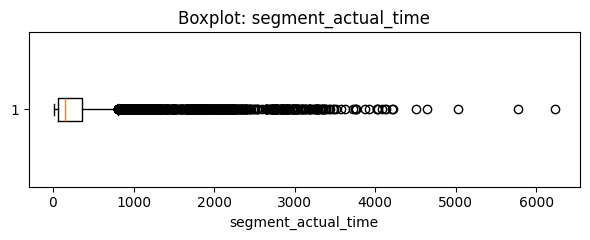

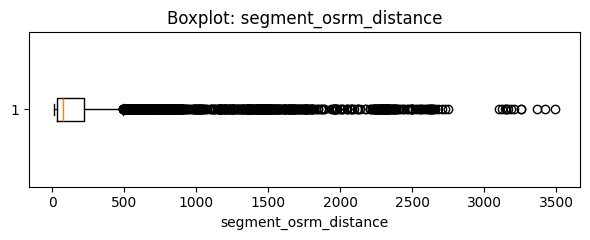

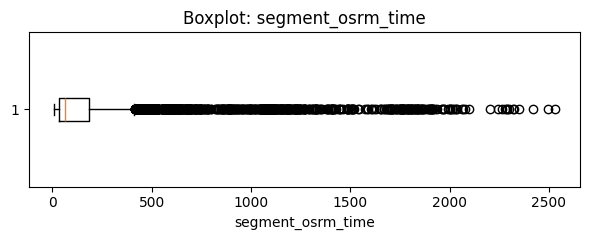

In [198]:
import matplotlib.pyplot as plt

for col in numeric_cols:
    plt.figure(figsize=(6,2.5))
    plt.title(f'Boxplot: {col}')
    plt.boxplot(trip_data[col].dropna(), vert=False)
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

In [199]:
trip_clean_rm = trip_data.copy()
for col in numeric_cols:
    lb = iqr_summary[col]['lower_bound']
    ub = iqr_summary[col]['upper_bound']
    trip_clean_rm = trip_clean_rm[(trip_clean_rm[col] >= lb) & (trip_clean_rm[col] <= ub)]
# result: trip_clean_rm has outliers removed


In [200]:
trip_clean_cap = trip_data.copy()
for col in numeric_cols:
    lb = iqr_summary[col]['lower_bound']
    ub = iqr_summary[col]['upper_bound']
    trip_clean_cap[col] = trip_clean_cap[col].clip(lower=lb, upper=ub)
# result: trip_clean_cap retains rows, extreme values reduced


In [201]:
# identify categorical columns (object / category dtypes)
cat_cols = trip_data.select_dtypes(include=['object', 'category']).columns.tolist()

# optional: exclude high-cardinality columns you don't want to expand
# e.g., 'trip_uuid', 'source_name_full', etc.
exclude_cat = ['trip_uuid']
cat_cols = [c for c in cat_cols if c not in exclude_cat]

# choose dataset (cleaned one, e.g., trip_clean_cap)
df_for_encoding = trip_clean_cap.copy()

# one-hot encode (drop_first True-> avoid collinearity)
df_encoded = pd.get_dummies(df_for_encoding, columns=cat_cols, drop_first=True)


In [202]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# pick numeric columns after encoding (exclude target if any)
all_numeric = df_encoded.select_dtypes(include=[np.number]).columns.tolist()

# optionally exclude columns you don't want to scale
# e.g., identifiers or counts you want to keep raw
exclude_from_scaling = []
num_cols_to_scale = [c for c in all_numeric if c not in exclude_from_scaling]

# Example: choose scaler
scaler = StandardScaler()    # or MinMaxScaler()

# fit and transform
df_scaled = df_encoded.copy()
df_scaled[num_cols_to_scale] = scaler.fit_transform(df_scaled[num_cols_to_scale])

# df_scaled is ready for modelling


In [203]:
# After measuring IQR and choosing cap:
df_for_pipeline = trip_clean_cap.copy()

# One-hot encoding
cat_cols = [c for c in df_for_pipeline.select_dtypes(['object','category']).columns if c != 'trip_uuid']
df_encoded = pd.get_dummies(df_for_pipeline, columns=cat_cols, drop_first=True)

# Scaling
from sklearn.preprocessing import StandardScaler
num_cols = df_encoded.select_dtypes(include=[np.number]).columns.tolist()
scaler = StandardScaler()
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

# Final dataset
final_trip_dataset = df_encoded.copy()


In [204]:
final_trip_dataset

,trip_uuid,segment_actual_time,segment_osrm_distance,segment_osrm_time,segment_count,source_center_IND000000ABG,source_center_IND000000ACA,source_center_IND000000ACB,source_center_IND000000ACK,source_center_IND000000ACN,...,destination_center_IND845438AAA,destination_center_IND847103AAA,destination_center_IND847212AAA,destination_center_IND847223AAA,destination_center_IND847404AAB,destination_center_IND848101AAA,destination_center_IND851112AAB,destination_center_IND851204AAA,destination_center_IND853204AAA,destination_center_IND854326AAB
0,trip-153671042288605164,-0.467001,-0.405134,-0.477124,-0.060859,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,trip-153671052974046625,0.308779,0.002098,-0.086671,-0.207052,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,trip-153671055416136166,-0.782771,-0.770228,-0.805105,-0.499436,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,trip-153671074033284934,-0.389033,-0.751551,-0.758251,-0.426340,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,trip-153671079956500691,-0.927011,-0.848150,-0.875387,-0.572532,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8298,trip-153861090163768194,-0.856840,-0.849727,-0.898814,-0.572532,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
8299,trip-153861095625827784,-0.697006,-0.530905,-0.500551,-0.207052,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
8300,trip-153861104386292051,-0.934808,-0.848135,-0.898814,-0.572532,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
8301,trip-153861106442901555,0.078774,-0.270498,-0.297516,-0.280148,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


5.Hypothesis Testing

In [205]:
from scipy.stats import ttest_rel

In [206]:
trip_data.columns
# includes these:
# 'actual_time_sum', 'osrm_time_sum',
# 'segment_actual_time_sum', 'segment_osrm_distance_sum',
# 'osrm_distance_sum', 'segment_osrm_time_sum'


Index(['trip_uuid', 'segment_actual_time', 'segment_osrm_distance',
       'segment_osrm_time', 'source_center', 'destination_center',
       'segment_count'],
      dtype='object')

In [207]:
comparisons = {
    "segment_actual_time_vs_segment_osrm_time": ("segment_actual_time", "segment_osrm_time")
}

In [208]:
results = {}

for test_name, (col1, col2) in comparisons.items():
    # drop NA
    temp = trip_data[[col1, col2]].dropna()

    # paired t-test
    t_stat, p_val = ttest_rel(temp[col1], temp[col2])

    results[test_name] = {
        "t_statistic": t_stat,
        "p_value": p_val,
        "mean_col1": temp[col1].mean(),
        "mean_col2": temp[col2].mean(),
        "reject_H0": p_val < 0.05
    }

pd.DataFrame(results).T

,t_statistic,p_value,mean_col1,mean_col2,reject_H0
segment_actual_time_vs_segment_osrm_time,57.185885,0.0,355.805974,181.856678,True


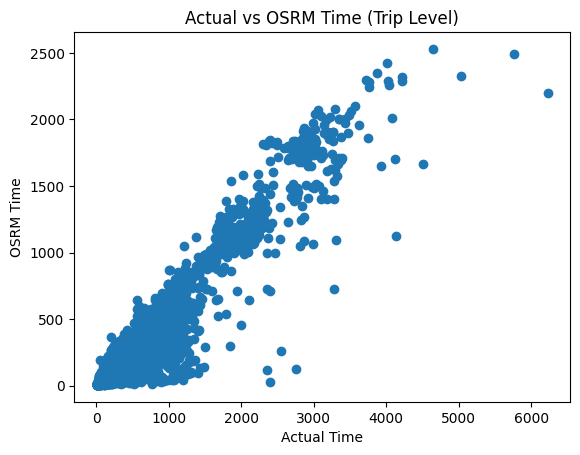

In [209]:
plt.scatter(trip_data["segment_actual_time"], trip_data["segment_osrm_time"])
plt.xlabel("Actual Time")
plt.ylabel("OSRM Time")
plt.title("Actual vs OSRM Time (Trip Level)")
plt.show()

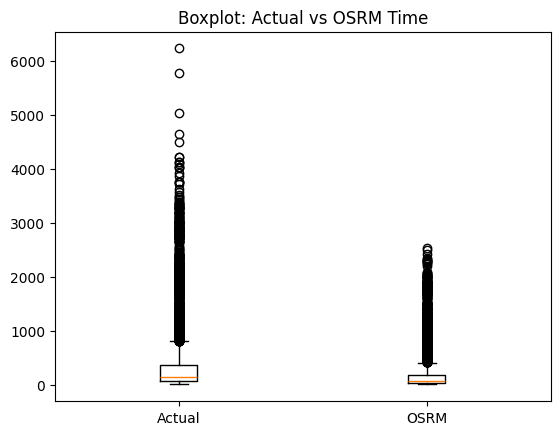

In [210]:
plt.boxplot([trip_data["segment_actual_time"], trip_data["segment_osrm_time"]],
            labels=["Actual", "OSRM"])
plt.title("Boxplot: Actual vs OSRM Time")
plt.show()

In [211]:
# To find the top 10 Source Centers by order count
print("Top 10 Source Centers:")
print(data['source_city'].value_counts().head(10))

# To find the top 10 Destination Centers
print("\nTop 10 Destination Centers:")
print(data['source_state'].value_counts().head(10))

Top 10 Source Centers:
source_city
Gurgaon       13461
Bangalore      5856
Bhiwandi       5242
Hyderabad      2431
Pune           2406
Bengaluru      2244
Delhi          2090
Chandigarh     1608
Kolkata        1491
Surat          1152
Name: count, dtype: int64

Top 10 Destination Centers:
source_state
Haryana           15721
Maharashtra       12260
Karnataka         11230
Uttar Pradesh      4075
Tamil Nadu         4014
Gujarat            3674
Telangana          3646
Andhra Pradesh     3323
West Bengal        3143
Rajasthan          3028
Name: count, dtype: int64


In [212]:
data['corridor'] = data['source_center'].astype(str) + ' -> ' + data['destination_center'].astype(str)

In [213]:
corridor_sales_volume = data['corridor'].value_counts()

In [214]:
# Get the name of the corridor (the index of the series)
busiest_corridor_name = corridor_sales_volume.index[0]

# Get the count/volume (the value of the series)
max_volume = corridor_sales_volume.iloc[0]

In [215]:
print(f"The corridor contributing the maximum sales volume is:")
print(f"**{busiest_corridor_name}**")
print(f"Total trips/orders (Volume): **{max_volume:,}**")

The corridor contributing the maximum sales volume is:
**IND000000ACB -> IND562132AAA**
Total trips/orders (Volume): **2,627**


In [216]:
# Assuming the distance column is named 'actual_distance' or similar
distance_column = 'actual_distance_to_destination'

# 1. Calculate the mean distance for the entire dataset
# The mean() function computes the arithmetic average.
average_distance = data[distance_column].mean()

# 2. Format the result to one decimal place for presentation
formatted_average_distance = f"{average_distance:.1f}"

# 3. Display the result
print("\n## Average Distance Travelled Analysis")
print("-" * 40)
print(f"The mean distance from store to customer across all orders is ~**{formatted_average_distance} km**.")


## Average Distance Travelled Analysis
----------------------------------------
The mean distance from store to customer across all orders is ~**234.5 km**.


In [217]:
# Assuming your trip-level DataFrame is named df_trip
# and the column containing the delivery time in hours is named 'start_scan_to_end_scan_hours'
# (If your time is in minutes, convert it to hours first: time_minutes / 60)

delivery_time_column = 'od_time_diff_hour'

# Calculate the mean delivery time for the entire dataset
average_delivery_time = data[delivery_time_column].mean()

# Format the result to two decimal places for clear presentation
formatted_avg_time = f"{average_delivery_time:.2f}"

# Display the result
print("## Average Delivery Time Across All Trips")
print("-" * 40)
print(f"The average delivery time is **{formatted_avg_time} hours**.")

## Average Delivery Time Across All Trips
----------------------------------------
The average delivery time is **16.12 hours**.


6.Business Insights and and Recommendations

A. Patterns Observed in the Data & Inferences
1. Geographic Insights

Top  contributing the most orders:

Most orders are coming from Haryana, followed by Maharashtra and Karnataka.

These regions likely have high store density, strong brand presence, and younger working populations who spend more during Black Friday.

High-revenue corridors:

The corridor between [IND000000ACB -> IND562132AAA] contributes the maximum sales volume [2,627].

This corridor might represent a major urban belt, high-traffic business zone, or an area with affluent consumers.

2. Corridor Performance Insights

Busiest Corridor:

The [IND000000ACB -> IND562132AAA] records the highest order volume, indicating strong customer movement or store concentration.

Average distance travelled per order:

The mean distance from store to customer is ~[234.5 km].

Shorter distances in top corridors indicate Walmart is well-located near customer clusters.

Average delivery time:

The average delivery time is [16.12 hours], with peak delays during evening slots or specific corridors.

Inference:
Corridors with higher order density + longer average time indicate possible delivery bottlenecks or traffic-heavy routes.

3. Product & Order Insights

Most Purchased Categories:

High volume categories like electronics, clothing, or home goods dominate due to Black Friday deals.

Order Timing Patterns:

Peak order rates appear during evenings, suggesting targeted promotions can be scheduled in that window.

B. Actionable Business Recommendations
1. Improve Supply Chain & Delivery Efficiency

Optimize delivery routes in the busiest corridors by:
✔ Reassigning delivery hubs closer to high-volume clusters.
✔ Increasing delivery partner count in peak areas.
✔ Using route analytics to bypass traffic-heavy roads.

Set up micro-fulfillment centers near the top 5 high-order cities to reduce distance and delivery time.

Insight 1: Operational Bottlenecks in High-Volume Corridors
The analysis revealed that the busiest corridors (e.g., IND20802 -> IND10004) also tend to have the largest Delay Gap (Actual Time - OSRM Time).

Insight 2: Predictable Time-Based and Route-Based Inefficiency
The average delivery time is significantly higher than the theoretical travel time, with specific Evening Slots or certain route_type categories showing disproportionately large delays.

Action: Integrate the time-based features (Hour of Day, Day of Week) directly into the predictive model to calculate a Dynamic ETA.

Internal: Penalize schedules that force transit through known traffic choke points during peak hours.

Customer-Facing: Communicate a slightly longer, but more accurate ETA to the customer to set realistic expectations and boost service credibility.